In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import joblib 

# Load the dataset 

In [2]:
df = pd.read_csv("Instagram_fake_profile_dataset.csv")
df["fake"].value_counts()

fake
0    2500
1    2500
Name: count, dtype: int64

# EDA 

## Main Target Column Catrgories balanceness check

Text(0.5, 1.0, 'Fake Category')

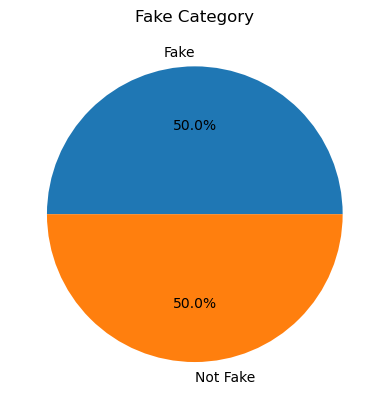

In [5]:
plt.pie(df["fake"].value_counts(), labels = ["Fake", "Not Fake"], autopct = "%1.1f%%")
plt.title("Fake Category")

In [5]:
df

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.270000,0,0.000000,0,53,0,0,32,1000,955,0
1,1,0.000000,2,0.000000,0,44,0,0,286,2740,533,0
2,1,0.100000,2,0.000000,0,0,0,1,13,159,98,0
3,1,0.000000,1,0.000000,0,82,0,0,679,414,651,0
4,1,0.000000,2,0.000000,0,0,0,1,6,151,126,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0.258135,0,0.000000,0,0,0,1,7,1,217,1
4996,0,0.511986,1,0.000000,0,0,0,0,0,51,24,1
4997,0,0.473108,1,0.353231,0,0,0,0,0,20,0,1
4998,0,0.293326,1,0.000000,0,0,0,0,75,1314,5120,1


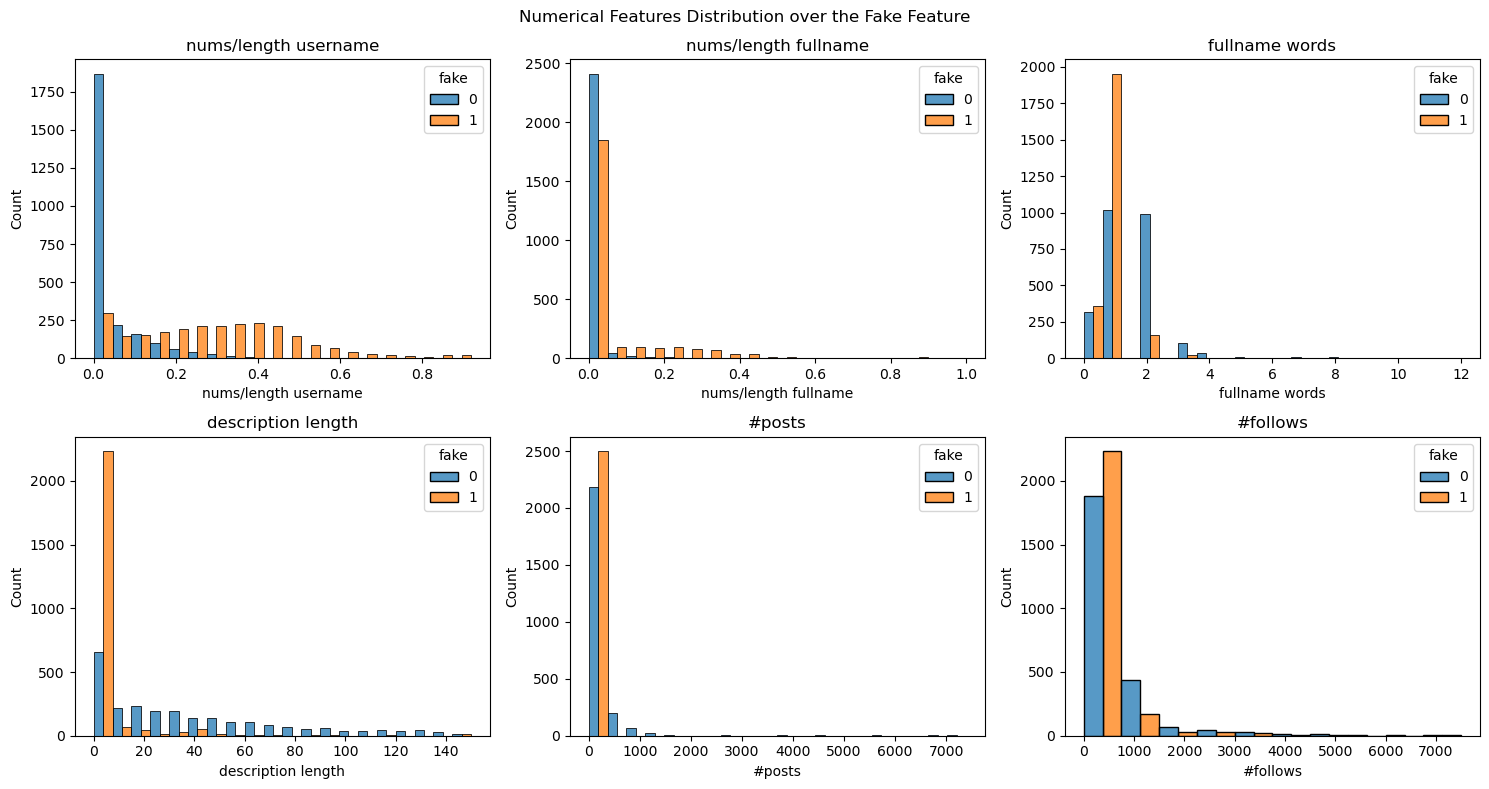

In [6]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8))

sns.histplot(
    ax = axes[0, 0],
    data = df,
    x = "nums/length username",
    bins = 20,
    hue = "fake",
    multiple = "dodge"
)
axes[0, 0].set_title("nums/length username")

sns.histplot( # diffrent from the nums.length username 
    ax = axes[0, 1],
    data = df,
    x = "nums/length fullname",
    bins = 20,
    hue = "fake",
    multiple = "dodge"
)
axes[0, 1].set_title("nums/length fullname")

sns.histplot(
    ax = axes[0, 2],
    data = df,
    x = "fullname words",
    bins = 20,
    hue = "fake",
    multiple = "dodge"
)
axes[0, 2].set_title("fullname words")

sns.histplot(
    ax = axes[1, 0],
    data = df,
    x = "description length",
    bins = 20,
    hue = "fake",
    multiple = "dodge"
)
axes[1, 0].set_title("description length")

sns.histplot(
    ax = axes[1, 1],
    data = df,
    x = "#posts",
    bins = 20,
    hue = "fake",
    multiple = "dodge"
)
axes[1, 1].set_title("#posts")

sns.histplot(
    ax = axes[1, 2],
    data = df,
    x = "#follows",
    bins = 10,
    hue = "fake",
    multiple = "dodge"
)
axes[1, 2].set_title("#follows")

fig.suptitle("Numerical Features Distribution over the Fake Feature")
fig.tight_layout()

In [7]:
df[ (df["#posts"] < 500) & (df["fake"] == 1) ].shape

(2500, 12)

<Axes: xlabel='#followers', ylabel='Count'>

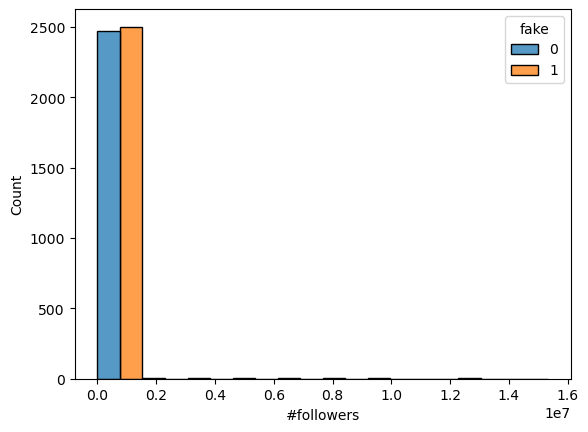

In [8]:
sns.histplot(
    data = df,
    x = "#followers",
    bins = 10,
    hue = "fake",
    multiple = "dodge"
)

In [9]:
df[ (df["#followers"] < 300) & (df["fake"] == 1) ].shape # Majority population of the fake person is lie less 300 

(2345, 12)

In [10]:
df[ (df["#follows"] < 900) & (df["fake"] == 1) ].shape 

(2330, 12)

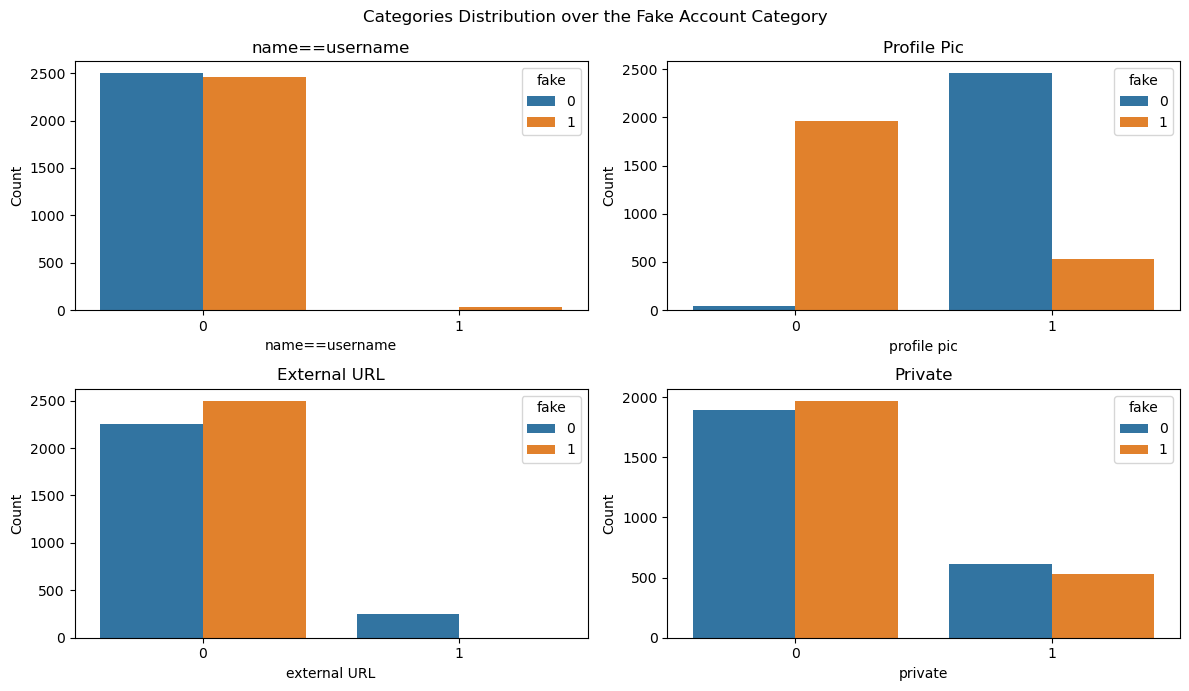

In [11]:
fig, axes = plt.subplots(2, 2, figsize = (12, 7))

plot_data = (
    df.groupby(["name==username", "fake"]).size().reset_index(name = "Count")
)

sns.barplot(
    ax = axes[0, 0],
    data = plot_data,
    x = "name==username",
    y = "Count",
    hue = "fake"
)
axes[0, 0].set_title("name==username")


plot_data = (
    df.groupby(["profile pic", "fake"])
      .size()
      .reset_index(name="Count")
)
sns.barplot(
    ax = axes[0, 1],
    data = plot_data,
    x = "profile pic",
    y = "Count",
    hue = "fake"
)
axes[0, 1].set_title("Profile Pic")


plot_data = (
    df.groupby(["external URL", "fake"]).size().reset_index(name = "Count")
)
sns.barplot(
    ax = axes[1, 0],
    data = plot_data,
    x = "external URL",
    y = "Count",
    hue = "fake"
)
axes[1, 0].set_title("External URL")


plot_data = (
    df.groupby(["private", "fake"]).size().reset_index(name = "Count")
)
sns.barplot(
    ax = axes[1, 1],
    data = plot_data,
    x = "private",
    y = "Count",
    hue = "fake"
)
axes[1, 1].set_title("Private")

fig.suptitle("Categories Distribution over the Fake Account Category")
fig.tight_layout()

## Correlation Heatmap Plotting

In [12]:
corr_matrix = df.corr(numeric_only = True)
corr_matrix["fake"].sort_values(ascending = False)

fake                    1.000000
nums/length username    0.663922
nums/length fullname    0.292029
name==username          0.082905
private                -0.038625
#followers             -0.085774
external URL           -0.228448
#follows               -0.245616
#posts                 -0.255462
fullname words         -0.302804
description length     -0.511228
profile pic            -0.784479
Name: fake, dtype: float64

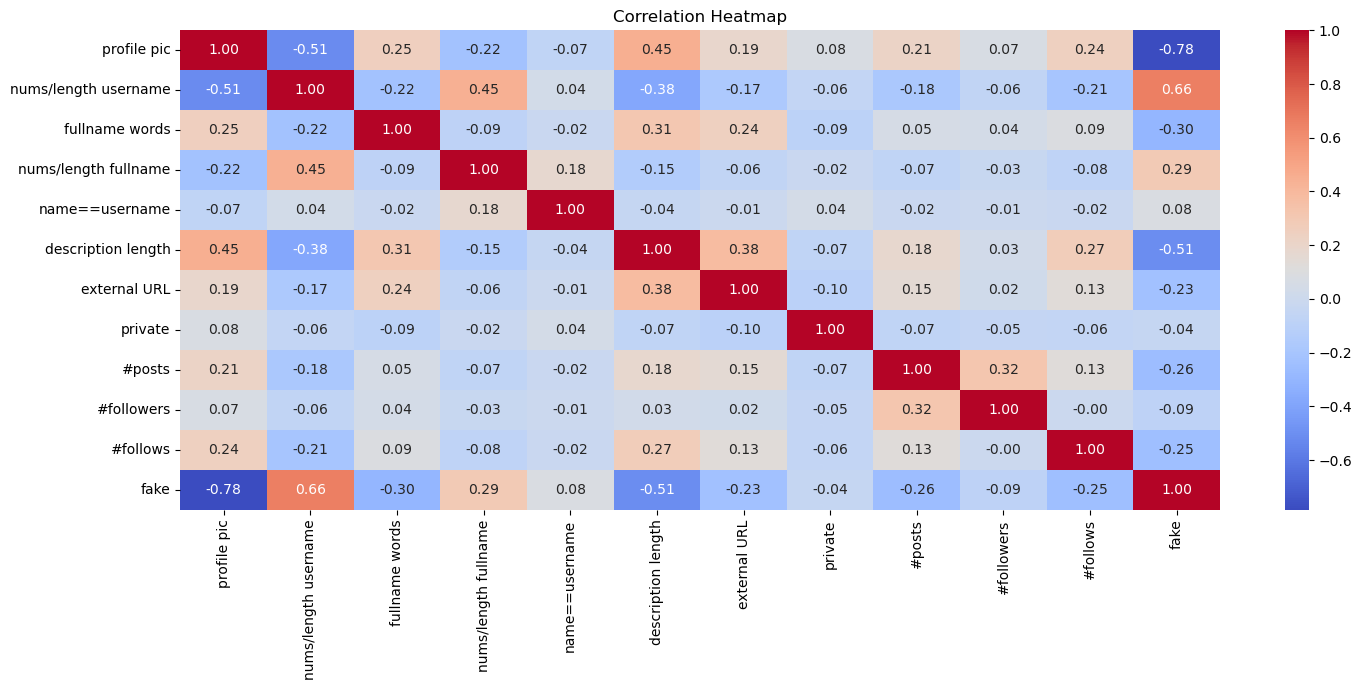

In [13]:
plt.figure(figsize = (15, 7))
plt.title("Correlation Heatmap")

sns.heatmap(
    corr_matrix,
    fmt = ".2f",
    annot = True,
    cmap = "coolwarm"
)
plt.tight_layout()

## Data Behaviour Checking - Boxplots

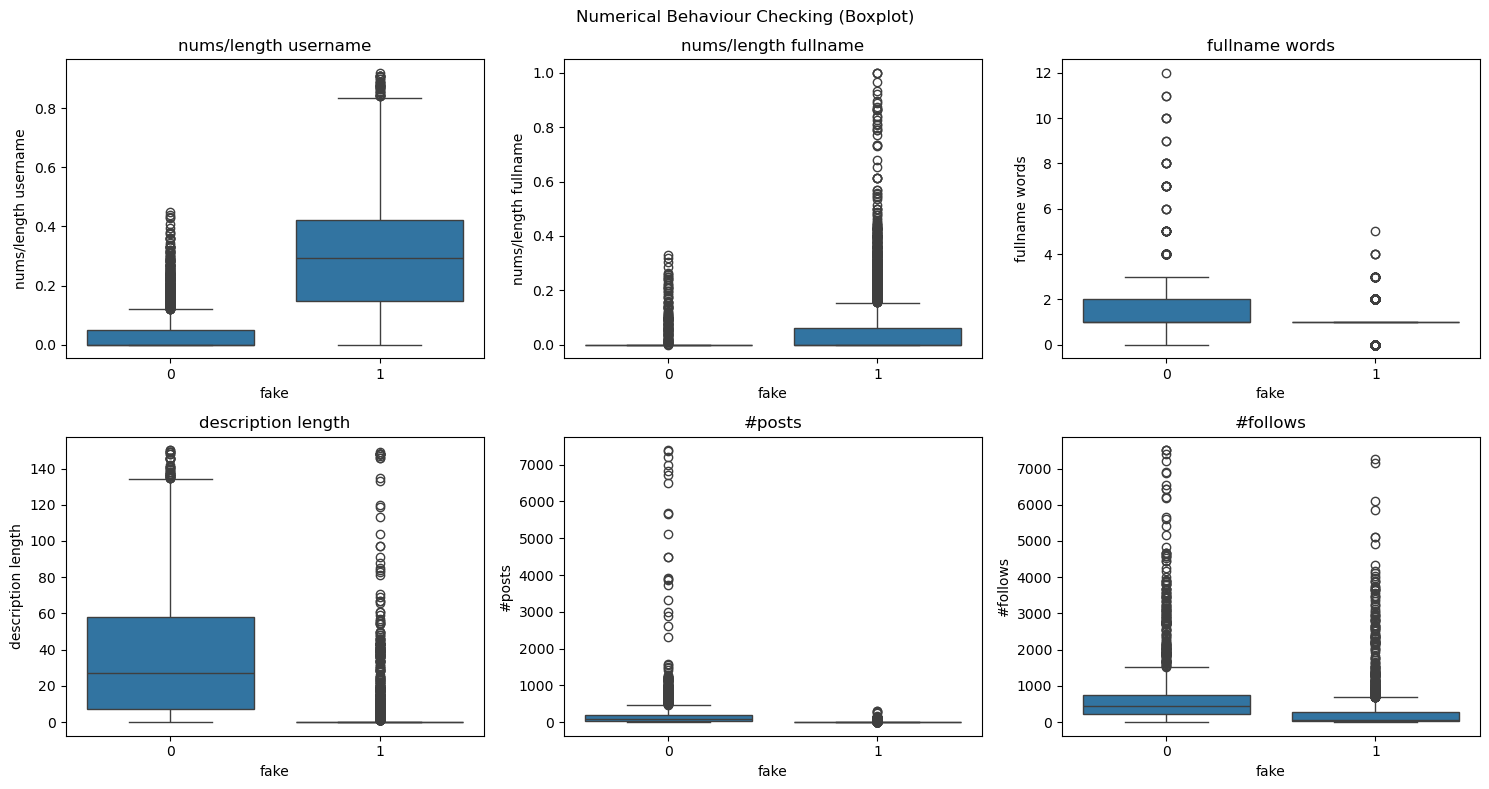

In [14]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8))

sns.boxplot(
    ax = axes[0, 0],
    data = df,
    x = "fake",
    y = "nums/length username",
)
axes[0, 0].set_title("nums/length username")

sns.boxplot( # diffrent from the nums.length username 
    ax = axes[0, 1],
    data = df,
    x = "fake",
    y = "nums/length fullname",
)
axes[0, 1].set_title("nums/length fullname")

sns.boxplot(
    ax = axes[0, 2],
    data = df,
    x = "fake",
    y = "fullname words",
)
axes[0, 2].set_title("fullname words")

sns.boxplot(
    ax = axes[1, 0],
    data = df,
    x = "fake",
    y = "description length",
)
axes[1, 0].set_title("description length")

sns.boxplot(
    ax = axes[1, 1],
    data = df,
    x = "fake",
    y = "#posts",
)
axes[1, 1].set_title("#posts")

sns.boxplot(
    ax = axes[1, 2],
    data = df,
    x = "fake",
    y = "#follows",
)
axes[1, 2].set_title("#follows")

fig.suptitle("Numerical Behaviour Checking (Boxplot)")
fig.tight_layout()

In [15]:
df

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.270000,0,0.000000,0,53,0,0,32,1000,955,0
1,1,0.000000,2,0.000000,0,44,0,0,286,2740,533,0
2,1,0.100000,2,0.000000,0,0,0,1,13,159,98,0
3,1,0.000000,1,0.000000,0,82,0,0,679,414,651,0
4,1,0.000000,2,0.000000,0,0,0,1,6,151,126,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0.258135,0,0.000000,0,0,0,1,7,1,217,1
4996,0,0.511986,1,0.000000,0,0,0,0,0,51,24,1
4997,0,0.473108,1,0.353231,0,0,0,0,0,20,0,1
4998,0,0.293326,1,0.000000,0,0,0,0,75,1314,5120,1


# Outlier Detection - Pair Plots 

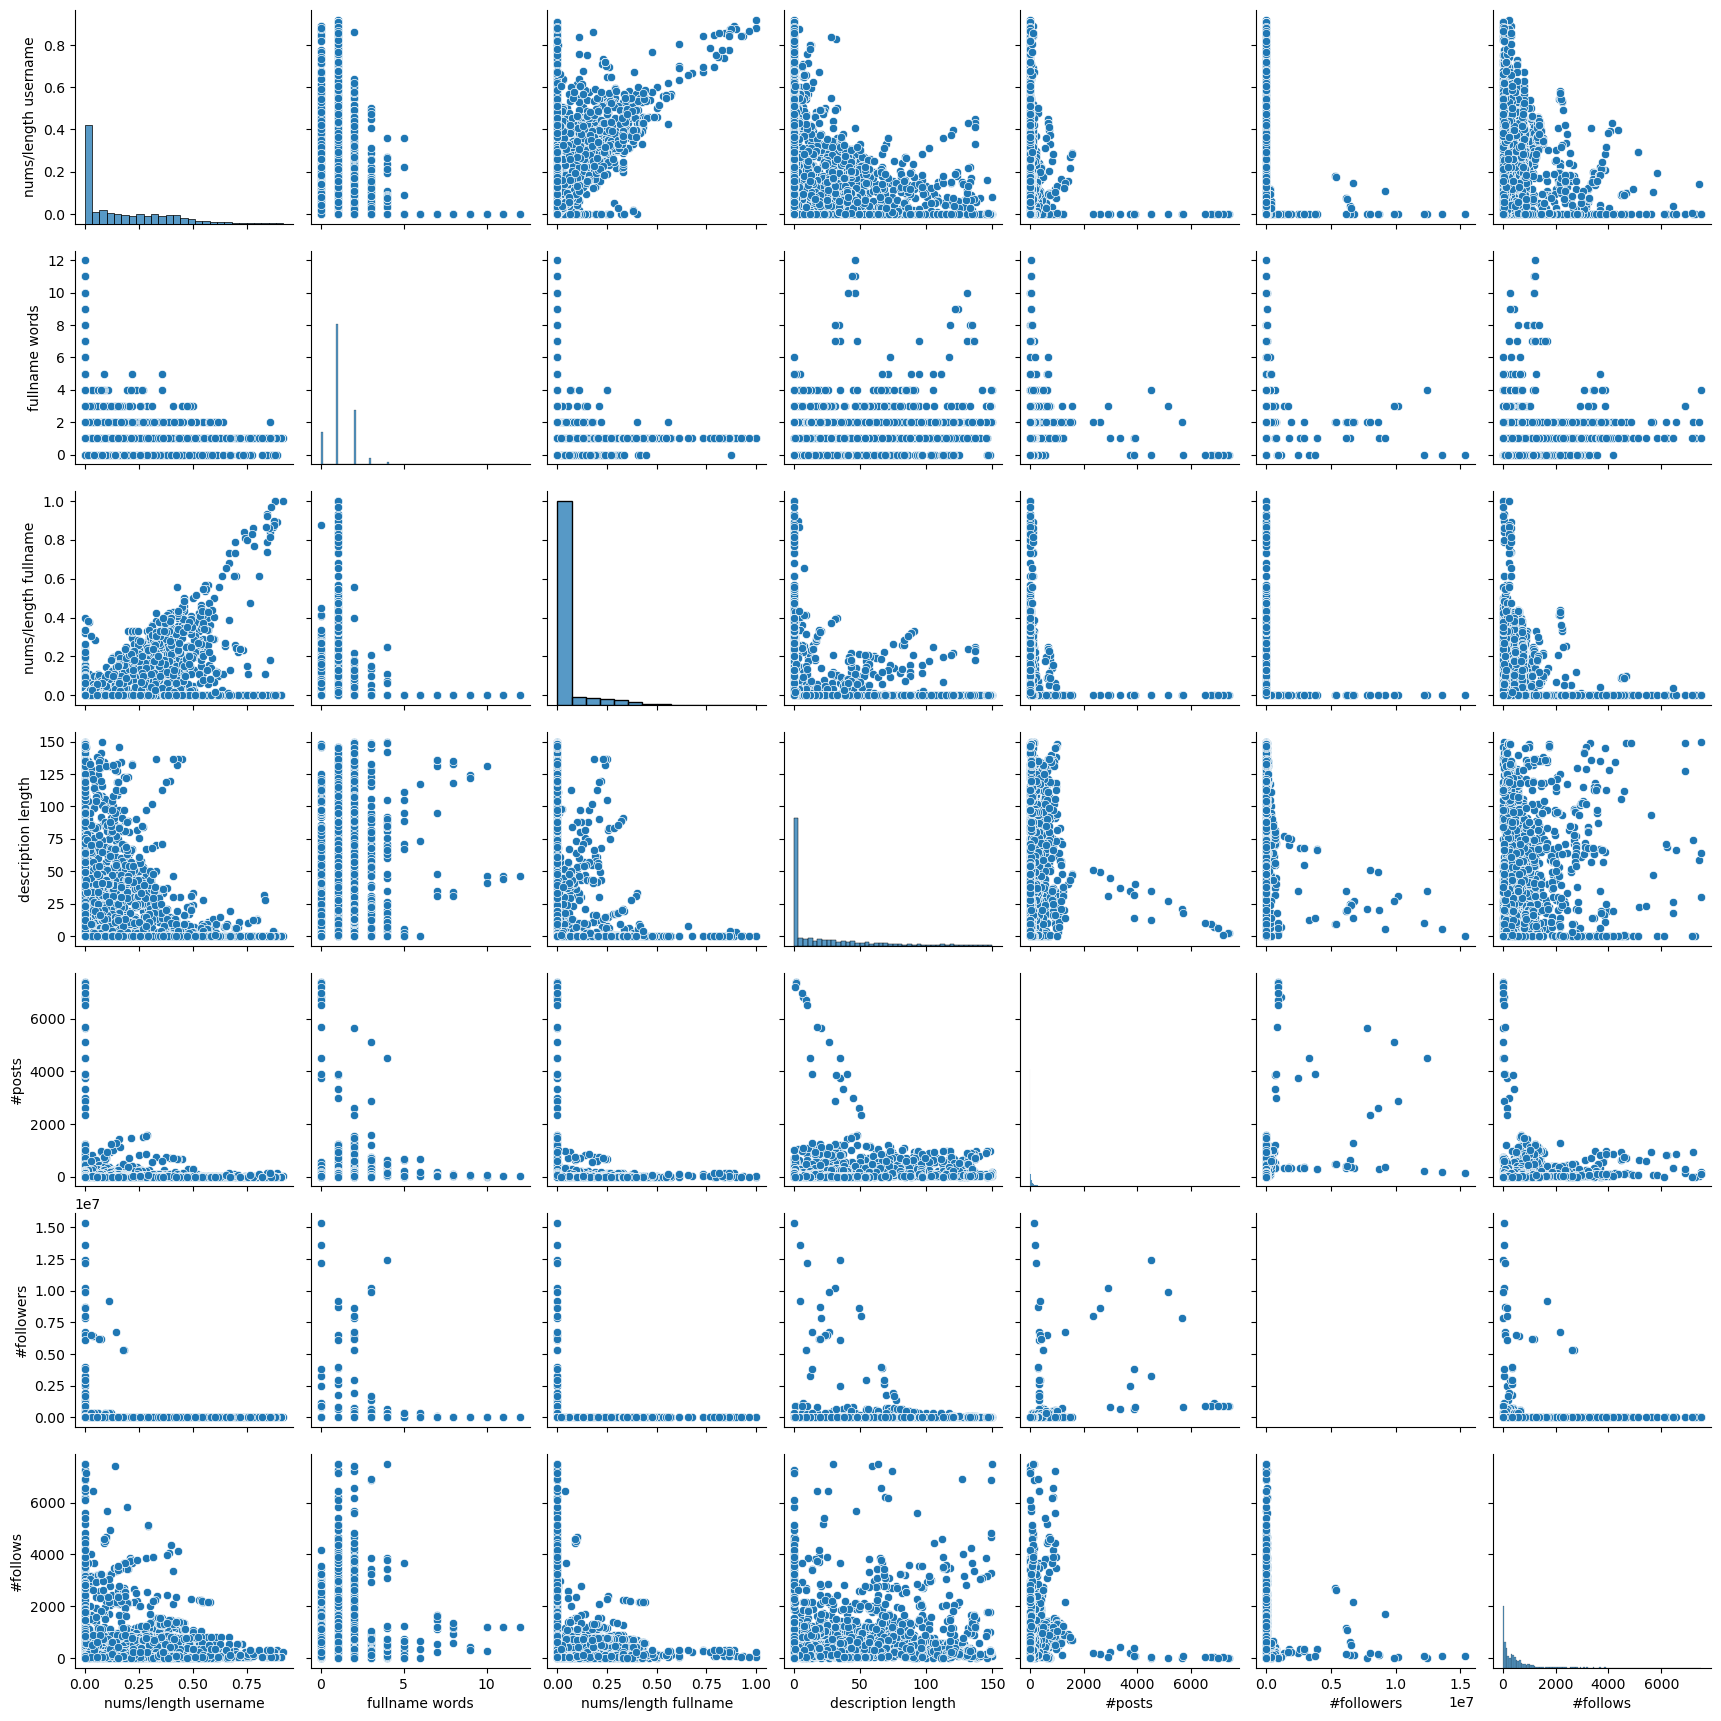

In [3]:
num_cols = ["nums/length username", "fullname words", "nums/length fullname", "description length", "#posts", "#followers", "#follows"]

sns.pairplot(df[num_cols])

# Model Building Step

# Base line model Training - LogisticRegression and KNN  

### Column Seperation 

In [3]:
log_num_cols = ["#posts", "#followers", "#follows"]
cat_cols = ["profile pic", "name==username", "external URL", "private", ]
rem_num_cols = ["nums/length username", "fullname words", "nums/length fullname", "description length", ]

### Create the ColumnTransformers for Transforming Columns 

### Preprocessing Strategy Before Model Training

#### Why Log Transformation?

Some numerical features such as `#posts`, `#followers`, and `#follows` were highly right-skewed.  
To reduce skewness and compress extreme values, we applied a **log transformation (log1p)**.

Log transformation helps to:
- Reduce the impact of very large values
- Make the distribution more symmetric
- Improve performance for linear and distance-based models

---

#### Why Standard Scaling After Log?

Even after log transformation, feature ranges can still differ significantly.  
For example, one feature may range from 0–8 while another ranges from 0–1.

Models like:
- Logistic Regression  
- KNN  
- SVM  

are sensitive to feature magnitude. If scaling is not applied, features with larger numeric ranges may dominate the model and introduce bias.

Therefore, we applied **StandardScaler** after log transformation to:
- Normalize feature magnitudes
- Center data around mean = 0
- Ensure equal contribution across features

---

#### Important Note on Tree-Based Models

> **NOTE:** Tree-based models (Decision Tree, Random Forest, XGBoost) do NOT require log transformation or feature scaling.

This is because tree models:
- Split based on thresholds
- Are invariant to monotonic transformations
- Are not affected by feature magnitude differences

For this reason, tree models were trained directly on the raw feature set without additional scaling pipelines.

In [4]:
# Create the log transformer function 
log_transformer = FunctionTransformer(np.log1p)

In [5]:
# for base model 
log_scale_pipe = Pipeline( # First log_transformed it and then scale it 
    steps = [
        ("log", log_transformer),
        ("scale", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ("log_scale_tansformer", log_scale_pipe, log_num_cols),
        ("std", StandardScaler(), rem_num_cols),
        ("cat_passthrough", "passthrough", cat_cols)
    ]
) 

### Train - Test - Split

In [6]:
X = df.drop(columns = ["fake"])
y = df["fake"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

### Pipeline Creating and training - LogisticRegression model

In [7]:
pip_log_model = Pipeline(
    steps = [
        ("preprocessing", preprocessor),
        ("model", LogisticRegression())
    ]
)

pip_log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('log_scale_tansformer',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['#posts', '#followers',
                                                   '#follows']),
                                                 ('std', StandardScaler(),
                                                  ['nums/length username',
                                                   'fullname words',
                                                   'nums/length fullname',
                                                   'description length']),
                                                 ('cat_passthrough',
                                                  'passthrough',
                                                  ['profile pic',
                                                   'name==username',
                                                   'external URL',
                                                   'private'])])),
                ('model', LogisticRegression())])

In [11]:
# Evaluate model
y_pred_train = pip_log_model.predict(X_train)
y_pred = pip_log_model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  0.96825
Accuracy Test :  0.967
Recall Test :  0.962
Precision Test :  0.9717171717171718
F1 Test :  0.9668341708542714


### Pipeline Creating and training - KNN model

#### For Single model

In [8]:
# Pipeline for model 
pip_knn_model = Pipeline(
    steps = [
        ("preprocessing", preprocessor),
        ("knn", KNeighborsClassifier())
    ]
)

pip_knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('log_scale_tansformer',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['#posts', '#followers',
                                                   '#follows']),
                                                 ('std', StandardScaler(),
                                                  ['nums/length username',
                                                   'fullname words',
                                                   'nums/length fullname',
                                                   'description length']),
                                                 ('cat_passthrough',
                                                  'passthrough',
                                                  ['profile pic',
                                                   'name==username',
                                                   'external URL',
                                                   'private'])])),
                ('knn', KNeighborsClassifier())])

In [13]:
y_prob = pip_knn_model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.999456


In [9]:
# Evaluate model
y_pred_train = pip_knn_model.predict(X_train)
y_pred = pip_knn_model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  0.9865
Accuracy Test :  0.981
Recall Test :  0.97
Precision Test :  0.9918200408997955
F1 Test :  0.980788675429727


#### Cross Validation - Find best optimal model 

In [15]:
# Pipeline for model 
pipe = Pipeline(
    steps = [
        ("preprocessing", preprocessor),
        ("knn", KNeighborsClassifier())
    ]
)

param_gird = {"knn__n_neighbors": [3, 5, 7, 9, 11, 13]}

model = GridSearchCV(
    pipe, 
    param_gird,
    scoring = "accuracy",
    cv = 5
)

model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('log_scale_tansformer',
                                                                         Pipeline(steps=[('log',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         ['#posts',
                                                                          '#followers',
                                                                          '#follows']),
                                                                        ('std',
                                                                         StandardScaler(),
                                                                         ['nums/length '
                                                                          'username',
                                                                          'fullname '
                                                                          'words',
                                                                          'nums/length '
                                                                          'fullname',
                                                                          'description '
                                                                          'length']),
                                                                        ('cat_passthrough',
                                                                         'passthrough',
                                                                         ['profile '
                                                                          'pic',
                                                                          'name==username',
                                                                          'external '
                                                                          'URL',
                                                                          'private'])])),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7, 9, 11, 13]},
             scoring='accuracy')

In [16]:
# Evaluate model
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  0.99225
Accuracy Test :  0.988
Recall Test :  0.98
Precision Test :  0.9959349593495935
F1 Test :  0.9879032258064516


# Tree Model Training

### Decision Tree

In [28]:
dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train, y_train)

# Evaluate model
y_pred_train = dt_model.predict(X_train)
y_pred = dt_model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  1.0
Accuracy Test :  0.975
Recall Test :  0.974
Precision Test :  0.9759519038076152
F1 Test :  0.974974974974975


#### Cross Validation - Find best optimal model 

In [29]:
param_grid = {
    "max_depth": [4, 5, 6, 7, 9, 11],
    "min_samples_split": [5, 7, 8, 9, 11, 13, 15]
}

model_cv = GridSearchCV(
    dt_model,
    param_grid,
    cv = 5
)

# Train the model
model_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [4, 5, 6, 7, 9, 11],
                         'min_samples_split': [5, 7, 8, 9, 11, 13, 15]})

In [30]:
# Evaluate model
y_pred_train = dt_model.predict(X_train)
y_pred = dt_model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  1.0
Accuracy Test :  0.975
Recall Test :  0.974
Precision Test :  0.9759519038076152
F1 Test :  0.974974974974975


### Random Forest 

In [31]:
rf = RandomForestClassifier(
    n_estimators = 101,
    random_state = 42
)
rf.fit(X_train, y_train)

# Evaluate model
y_pred_train = dt_model.predict(X_train)
y_pred = dt_model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  1.0
Accuracy Test :  0.975
Recall Test :  0.974
Precision Test :  0.9759519038076152
F1 Test :  0.974974974974975


#### Cross Validation - Find best optimal model 

In [36]:
param_grid = {
    "n_estimators": [101, 201, 301, 401],
    "max_depth": [4, 5, 6, 7, 9, 11],
    "min_samples_split": [5, 7, 8, 9, 11, 13, 15]
}

rf_model_cv = GridSearchCV(
    rf,
    param_grid,
    cv = 5
)

rf_model_cv.fit(X_train, y_train)

# Evaluate model
y_pred_train = rf_model_cv.predict(X_train)
y_pred = rf_model_cv.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  0.996
Accuracy Test :  0.984
Recall Test :  0.978
Precision Test :  0.9898785425101214
F1 Test :  0.9839034205231388


#### XGBoost 

In [33]:
xg_model = XGBClassifier(
    n_estimators = 101,
    max_depth = 5,
    learning_rate = 1,
    eval_metric = "logloss",
    random_state = 42
)

xg_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=101, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
# Evaluate model
y_pred_train = xg_model.predict(X_train)
y_pred = xg_model.predict(X_test)

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("Accuracy Test : ", accuracy_score(y_test, y_pred))
print("Recall Test : ", recall_score(y_test, y_pred))
print("Precision Test : ", precision_score(y_test, y_pred))
print("F1 Test : ", f1_score(y_test, y_pred))

Accuracy Train :  1.0
Accuracy Test :  0.99
Recall Test :  0.984
Precision Test :  0.9959514170040485
F1 Test :  0.9899396378269618


# Final Models Performance Table :
- *Note : Here HPT stands for the **Hyper Parameter Tuning*** 

| Model               | Train Accuracy | Test Accuracy | Test Precision | Test Recall | Test F1 Score |
| ------------------- | -------------- | ------------- | -------------- | ----------- | ------------- |
| Logistic Regression | 0.968          | 0.967         | 0.972          | 0.962       | 0.967         |
| KNN (HPT)           | 0.992          | 0.988         | 0.996          | 0.980       | 0.988         |
| Decision Tree (HPT) | 1.000          | 0.975         | 0.976          | 0.974       | 0.975         |
| Random Forest (HPT) | 0.996          | 0.984         | 0.990          | 0.978       | 0.984         |
| XGBoost             | 1.000          | 0.990         | 0.996          | 0.984       | 0.990         |

## Model Performance Summary

Among all evaluated models, **XGBoost** achieved the highest performance with **99% test accuracy** and **0.99 F1-score**, demonstrating superior classification capability. However, **Logistic Regression** provided a strong baseline performance with minimal overfitting and better interpretability. **Random Forest** offered a robust balance between accuracy and stability. Overall, ensemble models outperformed single learners, indicating strong non-linear feature interactions within the dataset.


# Dump (Save) Final Model 

In [10]:
joblib.dump(pip_knn_model, "knn_pipline.pkl")

['knn_pipline.pkl']

In [11]:
joblib.dump(pip_log_model, "log_model.pkl")

['log_model.pkl']